# Module 7 | Autoencoders in Deep Learning (DSC-360)

**Main ideas**

- Autoencoders learn compressed representations (encodings) by trying to reconstruct their inputs.
- They are trained in an unserpervised way using a type of reconstruction loss (usually MSE).
- Different variants (denoising, sparse, variational, convolutional, recurrent) target different properties.
    - Robustness
    - Sparsity
    - Generative Capability, etc.


## 1 | What is an auto encoder?

- a neural network that tries to reconstruct its input at the output.
- Architecture: **Input, Encoder, Bottleneck (latent space), Decoder, Output.**
- Trained with reconstruction loss:
$$
L(x, \hat{x}) = \| x - \hat{x} \|^2
$$

This is typically implemented as **Mean Squared Error (MSE)**:

$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{x}_i)^2
$$
- Unsupervised: we only need the inputs \(x\); target is \(x\) itself.
- Use Cases:
    - Dimensionally reduction (nonlinear PCA)
    - Denoising
    - Feature learning for downstream tasks
    - Anomaly detection via reconstruction error


In [22]:


import tensorflow as tf
import numpy as np
from scipy.spatial.transform import Rotation # used to rotate 3D points in space
import matplotlib.pyplot as plt

# Build linear undercomplete autoencoder (3, 2, 3)

encoder = tf.keras.Sequential([   # Define the encoder as a sequential model
    tf.keras.layers.Dense(2)      # One dense layer that maps 3D input down to 2D (linear by default) 
])

decoder = tf.keras.Sequential([   # Define the decoder as another sequential model
    tf.keras.layers.Dense(3)      # One dense layer that maps 2D latent code back to 3D
])

autoencoder = tf.keras.Sequential([encoder, decoder]) # Full AE = encoder followed by decoder

optimizer = tf.keras.optimizers.SGD(learning_rate=0.5) # Use SGD optimizer with relatively large LR for toy example 
autoencoder.compile(loss="mse", optimizer=optimizer)  # Train by minimizing MSE between input and output

In [23]:
# Generate 3D dataset on a noisy twisted ring
m = 60                                         # Number of data points
X = np.zeros((m, 3))                           # Initialize an (m x 3) array for 3D points
np.random.seed(42)                             # Fix NumPy random seed for reproducibility

angles = (np.random.rand(m) ** 3 + 0.5) * 2 * np.pi  # Sample angles, skewed distribution, in [0.5, 1.5] * 2π
X[:, 0], X[:, 1] = np.cos(angles), np.sin(angles) * 0.5  # Parametric 2D ring (ellipse: x = cos, y = 0.5 sin)
X += 0.28 * np.random.randn(m, 3)              # Add Gaussian noise to all three coordinates

X = Rotation.from_rotvec([np.pi/29, -np.pi/20, np.pi/4]).apply(X)
# Rotate the points in 3D space by a fixed rotation vector so the manifold is not axis-aligned

X_train = X + [0.2, 0, 0.2]                    # Shift all points in x and z directions for training data

history = autoencoder.fit(X_train, X_train,    # Train AE: inputs = X_train, targets = X_train
                          epochs=500,          # Number of training epochs
                          verbose=False)       # Suppress per-epoch output
codings = encoder.predict(X_train)             # Pass training data through encoder to get 2D latent codes


2025-11-20 08:15:22.117371: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


2/2 [==============================] - 0s 4ms/step


2025-11-20 08:15:26.343823: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


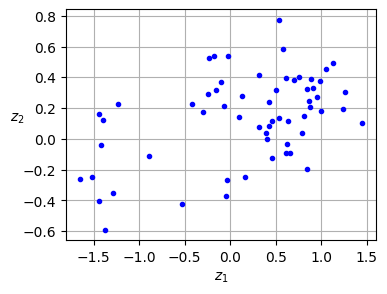

In [24]:
# Visulization 

plt.figure(figsize=(4, 3))
plt.plot(codings[:, 0], codings[:, 1], "b.")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$", rotation=0)
plt.grid(True)
plt.show()

## 2 | Performing PCA with an undercomplete linear AE

- Encoder: Dense(2), linear; Decoder: Dense(3).
- If the AE is:
    - Linear (no nonlinear axtivations),
    - Undercomplete (latent dimn < input dim),
    - Trained with MSE, 
then its encoder learns the same subspace as PCA (principal components).
- Here we compress 3D poinrs to 2D codes; plotting the codings is analous to plotting the first two principal components.

In [25]:
# stacked autoencoder on Fashion-MNIST

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
# Loads fashion-MNIST datasets: returns (train_images, train_labels), (test_images, test_labels)

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
#Unpacks into training (full) and test sets

X_train_full = X_train_full.astype(np.float32) / 255.0
# Comverts training images to flat32 and scale pixel values from [0,255] to [0,1]

X_test = X_test.astype(np.float32) / 255.0
# Same normalization for test images

X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
# Split the full training set into training set and validation set (last 500 images for validation)

y_train, y_valid = y_train_full[:-5000],y_train_full[:-5000]

In [26]:
# Define encoder, decoder, and stacked AE

tf.random.set_seed(42)

stacked_encoder = tf.keras.Sequential([             # Define the encoder part of the stacked AE
    tf.keras.layers.Flatten(),                      # Flatten each 2x28 image into a 784-dimensional vector
    tf.keras.layers.Dense(100, activation="relu"),  # Hidden layers with 100 neurons and ReLU activation
    tf.keras.layers.Dense(30, activation="relu"),   # Bottleneck layer: 30-dimensional latent representation

])

stacked_decoder = tf.keras.Sequential([             # Define decoder part of the tacked AE
    tf.keras.layers.Dense(100, activation="relu"),  # Hidden layer mirroring encoder width
    tf.keras.layers.Dense(28 * 28),                 # Output layer reconstructing 784 pixel values
    tf.keras.layers.Reshape([28, 28]),                     # Reshape 784-length vector back to 28x28 image
])

stacked_ae = tf.keras.Sequential([stacked_encoder, stacked_decoder])
# full autoencoder = encoder follwed by decoder

stacked_ae.compile(loss="mse", optimizer="nadam")
#Use MSE for reconstruction; Nadam optimizer (Adam + Nesterov momentum)

history = stacked_ae.fit(
    X_train, X_train,                       # Inputs and targets are both training images
    epochs=20,                              # Train for 20 epochs
    validation_data=(X_valid, X_valid)      # Monitor reconstruction loss on validation set
)

Epoch 1/20


2025-11-20 08:15:28.575268: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - ETA: 0s - loss: 0.1657

2025-11-20 08:15:47.118899: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - 20s 11ms/step - loss: 0.1657 - val_loss: 0.6552
Epoch 2/20
1719/1719 [==============================] - 23s 14ms/step - loss: 0.0697 - val_loss: 0.0285
Epoch 3/20
1719/1719 [==============================] - 20s 12ms/step - loss: 0.1218 - val_loss: 0.0327
Epoch 4/20
1719/1719 [==============================] - 15s 9ms/step - loss: 0.0980 - val_loss: 0.0406
Epoch 5/20
1719/1719 [==============================] - 16s 9ms/step - loss: 0.2292 - val_loss: 0.0686
Epoch 6/20
1719/1719 [==============================] - 16s 9ms/step - loss: 0.1034 - val_loss: 0.0463
Epoch 7/20
1719/1719 [==============================] - 23s 13ms/step - loss: 0.1973 - val_loss: 0.1333
Epoch 8/20
1719/1719 [==============================] - 17s 10ms/step - loss: 0.3805 - val_loss: 0.0447
Epoch 9/20
1719/1719 [==============================] - 16s 9ms/step - loss: 0.2639 - val_loss: 0.0786
Epoch 10/20
1719/1719 [==============================] - 15s 9ms/step - loss: 0

1/1 [==============================] - 0s 115ms/step


2025-11-20 08:23:23.735677: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


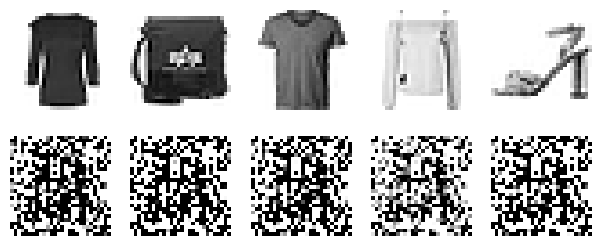

In [28]:
def plot_reconstructions(model, images=X_valid, n_images=5):
    # Model: trained autoencoder
    # Images: dataset to draw samples from (default = validation set)
    # n_images: number of images to display 

    reconstructions = np.clip(model.predict(images[:n_images]), 0, 1)
    # Use model to reconstruct the first n_images, then clip pixel values to [0,1] for visulization

    plt.figure(figsize=(n_images *1.5, 3))
    # Create a figure sized to fit n_images columns and 2 rows

    for i in range(n_images):
        # Loop over each simage index from 0 to n_images-1

                # Plot original image on the first row
        plt.subplot(2, n_images, 1 + i)                # 2 rows total, n_images columns,choose subplot index for row 1, column i+1
        plt.imshow(images[i], cmap="binary")                 # showoriginal image in grayscale ("binary" colormap)
        plt.axis("off")                                     # Hide axis ticks and frame


                # Plot reconstructed image on the second row
        plt.subplot(2, n_images, 1 + n_images + i)                    # 2nd row: index offset by n_images
        plt.imshow(reconstructions[i], cmap="binary")                 # Show reconsructe image in greyscale
        plt.axis("off")                                                # Hide axis again


# Call helper to visulaize reconstructions from the stacked AE
plot_reconstructions(stacked_ae)
plt.show()
#Render the figure with originals (top) and reconstructions (bottom)




## 3 | stacked autoencoder (dense)

- Input: 28x28 Fashion-MNIST scaled to [0,1]
- Encoder: fFlatten to Dense(100, relu) to Dense(30, relu)
- Decoder: Dense(100, relu) to Dense(784) to Rehsape(28x28)
- trained with MSE on X to X
- The 3D latent cod is a compressed representation f the image
- We can use the encoder's outputs with t-SNE for 2D visualization of the dataset

## 4 | Training one autoencoder at a time (greedy layer-wise)

- Define a helper `train_autoencoder(n_neurons, ...)` that:
    - Builds a 1-layer encoder + 1-layer decoder
    - Trains AE on current representation
    - Returns encoder, decoder, and encoded train/valid data.
- Pipeline:
    1. Flatten inputs, train AE1 (784 to 100 to 784).
    2. Use encoder1(X) as inputs, train AE2 (100 to 30 to 100).
    3. stack [Flatten, enc1, enc2, dec1, dec2, Reshape].
    4. Optionally fine-tune the full stacked AE..

## 5 | Tied Weights

- Custom `DenseTranspose` layer uses encoder weights transposed for decoder
- Reducedparameters and can help generalization

In [29]:
tf.random.set_seed(42)                         # Fix random seed for reproducible Conv AE weights

conv_encoder = tf.keras.Sequential([
    tf.keras.layers.Reshape([28, 28, 1]),      # Reshape flat or 2D images into (28,28,1) for conv layers
    tf.keras.layers.Conv2D(16, 3, padding="same", activation="relu"),
    # 2D conv with 16 filters, 3x3 kernel, keep spatial size ("same"), ReLU activation

    tf.keras.layers.MaxPool2D(pool_size=2),
    # Downsample feature maps by factor of 2 in each spatial dimension

    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    # Another conv: 32 filters, 3x3 kernel, same padding

    tf.keras.layers.MaxPool2D(pool_size=2),
    # Another downsampling by 2

    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    # Deeper conv layer with 64 filters for richer feature representation

    tf.keras.layers.MaxPool2D(pool_size=2),
    # Final pooling, further reduces spatial resolution

    tf.keras.layers.Conv2D(30, 3, padding="same", activation="relu"),
    # Conv layer with 30 filters; will be averaged over spatial dims

    tf.keras.layers.GlobalAvgPool2D(),
    # Global average pooling: average each feature map into a single value ⇒ 30D latent vector
])

conv_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(3 * 3 * 16),
    # Fully connected layer to expand 30D code back into 3x3x16 volume

    tf.keras.layers.Reshape((3, 3, 16)),
    # Reshape flat vector into a small 3D feature map (3x3 spatial, 16 channels)

    tf.keras.layers.Conv2DTranspose(32, 3, strides=2, activation="relu"),
    # Transposed convolution (deconvolution) layer: upsample feature map (from 3x3 to larger size)

    tf.keras.layers.Conv2DTranspose(16, 3, strides=2, padding="same", activation="relu"),
    # Another transposed conv, upsample again and reduce channels to 16

    tf.keras.layers.Conv2DTranspose(1, 3, strides=2, padding="same"),
    # Final transposed conv: upsample to ~28x28, single output channel, no activation

    tf.keras.layers.Reshape([28, 28]),
    # Reshape final (28,28,1) to (28,28) for grayscale image
])

conv_ae = tf.keras.Sequential([conv_encoder, conv_decoder])
# Full convolutional autoencoder: encoder followed by decoder

conv_ae.compile(loss="mse", optimizer="nadam")
# Use MSE reconstruction loss; Nadam optimizer

history = conv_ae.fit(X_train, X_train,
                      epochs=10,
                      validation_data=(X_valid, X_valid))
# Train Conv AE on Fashion-MNIST for 10 epochs, monitoring validation reconstruction


Epoch 1/10


2025-11-20 08:23:34.163141: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - ETA: 0s - loss: 0.0338

2025-11-20 08:24:20.615295: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - 50s 24ms/step - loss: 0.0338 - val_loss: 0.0236
Epoch 2/10
1719/1719 [==============================] - 37s 22ms/step - loss: 0.0212 - val_loss: 0.0194
Epoch 3/10
1719/1719 [==============================] - 30s 17ms/step - loss: 0.0183 - val_loss: 0.0176
Epoch 4/10
1719/1719 [==============================] - 70s 41ms/step - loss: 0.0167 - val_loss: 0.0159
Epoch 5/10
1719/1719 [==============================] - 34s 20ms/step - loss: 0.0156 - val_loss: 0.0150
Epoch 6/10
1719/1719 [==============================] - 28s 17ms/step - loss: 0.0147 - val_loss: 0.0144
Epoch 7/10
1719/1719 [==============================] - 27s 16ms/step - loss: 0.0141 - val_loss: 0.0139
Epoch 8/10
1719/1719 [==============================] - 36s 21ms/step - loss: 0.0136 - val_loss: 0.0140
Epoch 9/10
1719/1719 [==============================] - 39s 23ms/step - loss: 0.0131 - val_loss: 0.0131
Epoch 10/10
1719/1719 [==============================] - 65s 38ms/step - lo

In [30]:
# Recurrent autoencoder (LSTM-based)

recurrent_encoder = tf.keras.Sequential([
    tf.keras.layers.LSTM(100, return_sequences=True),
    # First LSTM layer with 100 units; return full sequence (one output per time step)

    tf.keras.layers.LSTM(30)
    # Second LSTM layer with 30 units; by default returns only the final hidden state (30D code)
])

recurrent_decoder = tf.keras.Sequential([
    tf.keras.layers.RepeatVector(28),
    # Take the 30D latent vector and repeat it 28 times (sequence length = 28 time steps)

    tf.keras.layers.LSTM(100, return_sequences=True),
    # LSTM that processes the repeated latent sequence and outputs a 100D vector at each time step

    tf.keras.layers.Dense(28)
    # Dense layer applied at each time step; outputs a vector of length 28 (one row of pixels)
])

recurrent_ae = tf.keras.Sequential([recurrent_encoder, recurrent_decoder])
# Full recurrent AE: encoder LSTMs → compressed vector → decoder LSTMs

recurrent_ae.compile(loss="mse", optimizer="nadam")
# MSE reconstruction loss; Nadam optimizer

history = recurrent_ae.fit(X_train, X_train,
                           epochs=10,
                           validation_data=(X_valid, X_valid))
# Train for 10 epochs, treating each 28x28 image as a sequence of 28 rows


Epoch 1/10


2025-11-20 08:37:41.270496: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:37:41.821893: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:37:42.454513: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:37:42.769490: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:37:43.794069: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:37:45.136614: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:37:45.513559: I tensorflow/core/grappler/optimizers/cust

1719/1719 [==============================] - ETA: 0s - loss: 0.0290

2025-11-20 08:38:35.943859: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:38:36.064034: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:38:36.147396: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-20 08:38:36.221336: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1719/1719 [==============================] - 64s 31ms/step - loss: 0.0290 - val_loss: 0.0217
Epoch 2/10
1719/1719 [==============================] - 46s 26ms/step - loss: 0.0192 - val_loss: 0.0180
Epoch 3/10
1719/1719 [==============================] - 44s 26ms/step - loss: 0.0163 - val_loss: 0.0161
Epoch 4/10
1719/1719 [==============================] - 45s 26ms/step - loss: 0.0147 - val_loss: 0.0138
Epoch 5/10
1719/1719 [==============================] - 44s 25ms/step - loss: 0.0135 - val_loss: 0.0130
Epoch 6/10
1719/1719 [==============================] - 63s 36ms/step - loss: 0.0126 - val_loss: 0.0121
Epoch 7/10
1719/1719 [==============================] - 44s 25ms/step - loss: 0.0119 - val_loss: 0.0117
Epoch 8/10
1719/1719 [==============================] - 47s 28ms/step - loss: 0.0114 - val_loss: 0.0114
Epoch 9/10
1719/1719 [==============================] - 45s 26ms/step - loss: 0.0109 - val_loss: 0.0108
Epoch 10/10
1719/1719 [==============================] - 44s 25ms/step - lo

## 6 | Convolutional and recurrent autoencoders

- **Conv AE**:
  - Uses Conv2D + MaxPool in encoder, Conv2DTranspose in decoder.
  - Learns spatially-local features and is more parameter-efficient on images.
- **Recurrent AE**:
  - Treats each image row as a time step (sequence length = 28).
  - LSTMs in encoder/decoder capture sequential structure.
  - More natural for genuine sequence data (text, time series).


In [ ]:
dropout_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    # Flatten 28x28 image to length-784 vector

    tf.keras.layers.Dropout(0.5),
    # Randomly set 50% of inputs to zero during training to simulate corruption/noise

    tf.keras.layers.Dense(100, activation="relu"),
    # Hidden dense layer with 100 units and ReLU activation

    tf.keras.layers.Dense(30, activation="relu"),
    # Bottleneck layer (latent code) with 30 units
])

dropout_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    # Mirror hidden dense layer

    tf.keras.layers.Dense(28 * 28),
    # Output layer reconstructing 784 pixel values

    tf.keras.layers.Reshape([28, 28]),
    # Reshape back into a 2D image
])

dropout_ae = tf.keras.Sequential([dropout_encoder, dropout_decoder])
# Full denoising autoencoder = encoder + decoder

dropout_ae.compile(loss="mse", optimizer="nadam")
# Train with MSE reconstruction loss and Nadam optimizer

history = dropout_ae.fit(X_train, X_train,
                         epochs=10,
                         validation_data=(X_valid, X_valid))
# The noise is only in the encoder; targets are the original clean images


In [ ]:
# Sparse AE (L1 Activity)

sparse_l1_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    # Flatten input image to 784 dims

    tf.keras.layers.Dense(100, activation="relu"),
    # Hidden dense layer

    tf.keras.layers.Dense(300, activation="sigmoid"),
    # Latent layer with 300 units, sigmoid activation (outputs in (0,1))

    tf.keras.layers.ActivityRegularization(l1=1e-4),
    # Add L1 penalty on activations => encourages many activations to be near 0 (sparsity)
])

sparse_l1_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    # Hidden layer mirroring encoder

    tf.keras.layers.Dense(28 * 28),
    # Output layer reconstructing 784 pixels

    tf.keras.layers.Reshape([28, 28]),
    # Reshape to 2D image
])

sparse_l1_ae = tf.keras.Sequential([sparse_l1_encoder, sparse_l1_decoder])
# Combine encoder and decoder into one sparse AE model

sparse_l1_ae.compile(loss="mse", optimizer="nadam")
# Standard reconstruction loss with Nadam optimizer



In [ ]:
# Regularizer definition

kl_divergence = tf.keras.losses.kullback_leibler_divergence
# Shortcut to Keras' KL divergence function

class KLDivergenceRegularizer(tf.keras.regularizers.Regularizer):
    # Custom Regularizer class to enforce sparsity via KL divergence

    def __init__(self, weight, target):
        self.weight = weight   # Scalar that scales the strength of the regularization
        self.target = target   # Desired average activation (e.g., 0.1)

    def __call__(self, inputs):
        # inputs: activations of the layer we are regularizing
        mean_activities = tf.reduce_mean(inputs, axis=0)
        # Compute the mean activation over the batch for each neuron

        return self.weight * (
            kl_divergence(self.target, mean_activities) +
            kl_divergence(1. - self.target, 1. - mean_activities)
        )
        # KL(p || q) + KL(1-p || 1-q):
        # penalizes deviation of mean_activities from target in both directions


In [ ]:
# Applying it to the encoder

kld_reg = KLDivergenceRegularizer(weight=5e-3, target=0.1)
# Instantiate regularizer: encourages each neuron's average activation ≈ 0.1

sparse_kl_encoder = tf.keras.Sequential([
    tf.keras.layers.Flatten(),
    # Flatten input image

    tf.keras.layers.Dense(100, activation="relu"),
    # Hidden layer

    tf.keras.layers.Dense(
        300, activation="sigmoid",
        activity_regularizer=kld_reg
    ),
    # Latent layer with 300 sigmoid units,
    # and our custom KL regularizer applied to their activations
])

sparse_kl_decoder = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    # Hidden reconstructing layer

    tf.keras.layers.Dense(28 * 28),
    # Output layer reconstructing pixel intensities

    tf.keras.layers.Reshape([28, 28]),
    # Reshape back to 2D image
])

sparse_kl_ae = tf.keras.Sequential([sparse_kl_encoder, sparse_kl_decoder])
# Full sparse AE using KL divergence for sparsity

sparse_kl_ae.compile(loss="mse", optimizer="nadam")
# Same reconstruction objective; sparsity comes from the extra regularizer term


## 7| Denoising and sparse autoencoders

- **Denoising AE**:
  - Add noise in encoder (Dropout or GaussianNoise).
  - Target = original image ⇒ model learns to remove noise.
- **Sparse AE**:
  - Latent layer encouraged to have low average activation.
  - Implemented via:
    - L1 (activity) regularization, or
    - Custom KL-divergence regularizer that pushes mean activations toward a target sparsity.


## 8 | Variational AE, semantic hashing, and GANs (conceptual recap)

- **VAE**:
  - Encoder outputs mean and log-variance of latent Gaussian.
  - Reparameterization trick: sample \(z = \mu + \sigma \odot \epsilon\).
  - Loss = reconstruction loss + KL divergence to standard normal.
  - Can sample \(z \sim \mathcal N(0, I)\) and decode to generate new images.

- **Semantic hashing AE**:
  - Latent layer: 16 sigmoid units + noise.
  - Round outputs to 0/1 to form 16-bit binary hash for each image.

- **GAN / DCGAN (extra)**:
  - Generator maps random noise → synthetic images.
  - Discriminator learns to distinguish real vs fake.
  - Trained adversarially; used for high-quality image generation.
